## Asiáticas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# Parámetros

S0 = 670
K = 680
r = 0.04
sigma = 0.17
N = 30          # numero de días
T = N/365       # tiempo al venc.
M = 10000       # numero de simulaciones
dt = T/N

Z = np.random.standard_normal((M,N))

retornos = (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z

S_paths = S0 * np.exp(np.cumsum(retornos, axis = 1))
S_paths = np.insert(S_paths, 0, S0, axis = 1)

# vector de precios al vencimiento
ST = S_paths[:,-1]
# vector de precios promedio de fluctuacion del subyacente
S_media = S_paths.mean(axis=1)

europea = np.exp(-r * T) * np.maximum(ST - K, 0)
asiatica = np.exp(-r * T) * np.maximum(S_media - K, 0)

# analítica Black Scholes
d1 = (np.log(S0 / K) + (r + 0.5 * sigma **2) * T / sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
bs_call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print("Precio Asiatica:",asiatica.mean())
print("Precio Europea:",europea.mean())
print("Precio Black Scholes:",bs_call)

Precio Asiatica: 3.866276841643614
Precio Europea: 9.468254937075375
Precio Black Scholes: 9.308744964731545


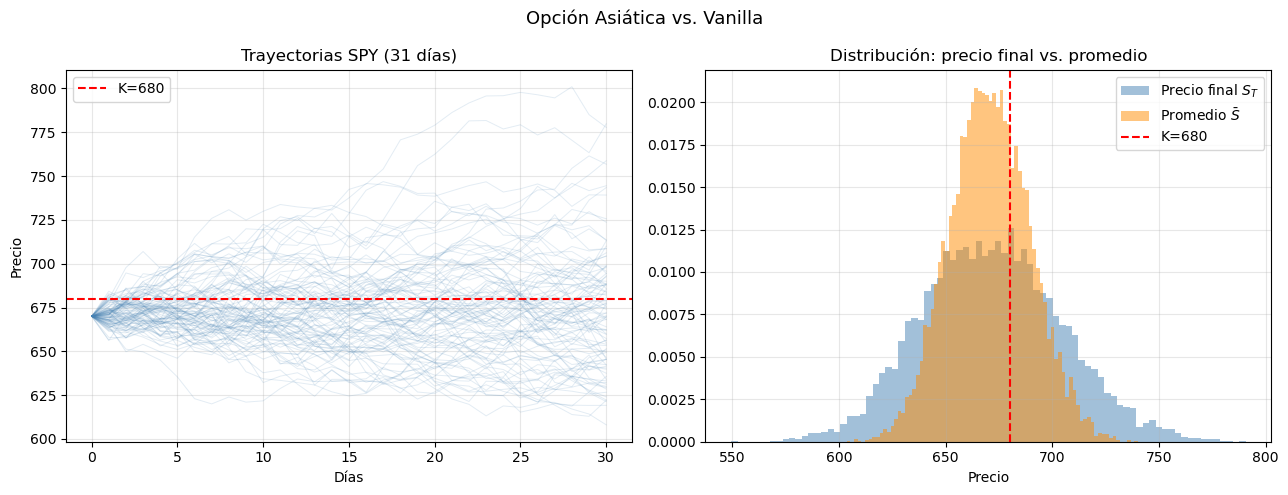

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trayectorias con el promedio marcado
for i in range(100):
    axes[0].plot(S_paths[i], alpha=0.15, linewidth=0.7, color='steelblue')
axes[0].axhline(K, color='red', linestyle='--', linewidth=1.5, label=f'K={K}')
axes[0].set_title('Trayectorias SPY (31 días)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución: precio final vs. promedio
axes[1].hist(ST,      bins=80, density=True, alpha=0.5,
             color='steelblue', label='Precio final $S_T$')
axes[1].hist(S_media, bins=80, density=True, alpha=0.5,
             color='darkorange', label='Promedio $\\bar{S}$')
axes[1].axvline(K, color='red', linestyle='--', label=f'K={K}')
axes[1].set_title('Distribución: precio final vs. promedio')
axes[1].set_xlabel('Precio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Opción Asiática vs. Vanilla', fontsize=13)
plt.tight_layout()
plt.show()

## Opciones con Barrera

In [3]:
B_up = 710

S_max = S_paths.max(axis=1)


# up and out
activa_up_and_out = (S_max < B_up)
call_up_and_out = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_out

# up and out
activa_up_and_in = (S_max > B_up)
call_up_and_in = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_in

print("up and out: ", call_up_and_out.mean())
print("up and in: ", call_up_and_in.mean())
print("europea", europea.mean())
print("comprobacion", call_up_and_out.mean() + call_up_and_in.mean()  )

up and out:  2.3146572053413834
up and in:  7.153597731733993
europea 9.468254937075375
comprobacion 9.468254937075375


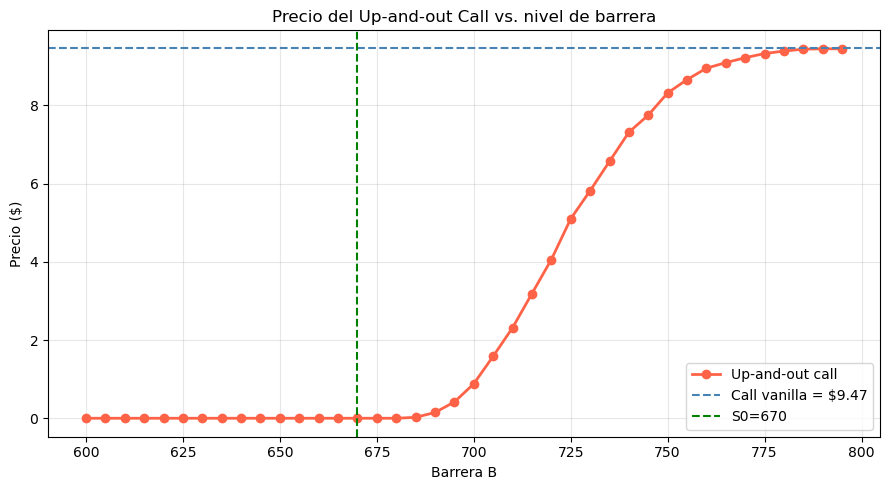

In [4]:
B_range = np.arange(600, 800, 5)   # barreras superiores
precios_uao = []

for b in B_range:
    s_max_b = S_paths.max(axis=1)
    precio  = np.exp(-r*T) * np.maximum(ST - K, 0) * (s_max_b < b)
    precios_uao.append(precio.mean())

plt.figure(figsize=(9, 5))
plt.plot(B_range, precios_uao, color='tomato', linewidth=2, marker='o',
         label='Up-and-out call')
plt.axhline(europea.mean(), color='steelblue', linestyle='--',
            linewidth=1.5, label=f'Call vanilla = ${europea.mean():.2f}')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Barrera B')
plt.ylabel('Precio ($)')
plt.title('Precio del Up-and-out Call vs. nivel de barrera')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Preguntas

- La opción asiática es más barata que la vanilla. ¿Siempre es así? ¿Puedes pensar en algún caso donde fueran igual de caras?

En términos generales, la opción asiática suele ser más económica que la opción vanilla. Esto se debe a que su valor depende del promedio del precio del activo durante el tiempo, en lugar de depender únicamente del precio final. Al considerar un promedio, las variaciones extremas se reducen, lo que implica menor riesgo y, por lo tanto, un menor precio. Sin embargo, no siempre ocurre así. En situaciones donde el periodo de promediado es muy corto o comienza cerca del vencimiento, el comportamiento de ambas opciones se vuelve muy similar. En estos casos, sus precios pueden ser prácticamente iguales.

- Verificaste que up-and-in + up-and-out = vanilla. ¿Qué implica eso para el pricing? ¿Puedes usarlo para encontrar el precio de una si conoces la otra?

Los resultados muestran que el precio del up-and-out es 2.31, el del up-and-in es 7.15, y su suma es 9.47, que coincide exactamente con el precio de la opción vanilla. Esto implica que ambas opciones con barrera son complementarias, ya que en cada trayectoria del activo la barrera se activa o no se activa, pero no ambas cosas al mismo tiempo, por lo que juntas replican el comportamiento de la opción estándar. Esta relación es muy útil en la valuación, ya que permite calcular el precio de una de las opciones si se conoce la otra, restando su valor al precio de la opción vanilla.

- Si la barrera B está muy cerca de S0, el up-and-out call casi no vale nada. ¿Por qué? ¿Y si la barrera está muy lejos?

Cuando la barrera B está muy cerca del precio inicial So=670, el valor del up-and-out es prácticamente nulo, debido a que es muy probable que el precio del activo alcance la barrera rápidamente, lo que provoca la cancelación de la opción antes de generar beneficios. Por el contrario, si la barrera se encuentra muy alejada, la probabilidad de alcanzarla es baja, por lo que la opción casi nunca se cancela y su precio se aproxima al de una opción vanilla, que en este caso es aproximadamente 9.47.

- ¿Por qué Monte Carlo es especialmente apropiado para opciones exóticas? ¿Cuál es su limitación principal vs. soluciones analíticas?

El método de Monte Carlo es especialmente útil para valuar opciones exóticas porque permite simular múltiples trayectorias del precio del activo y calcular el payoff en cada una de ellas, incluso cuando la opción depende de toda la trayectoria y no solo del valor final, como ocurre con las opciones asiáticas o de barrera. Además, es un método flexible que se adapta a diferentes condiciones. Sin embargo, su principal limitación es el alto costo computacional, ya que para mejorar la precisión se requiere un gran número de simulaciones, debido a que el error disminuye a una tasa proporcional a 1/raiz(N). En comparación, las soluciones analíticas, cuando existen, ofrecen resultados exactos de manera inmediata y sin incertidumbre estadística